In [ ]:
!pip install transformers torch requests matplotlib tqdm

In [ ]:
import torch
import requests
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

BASE_URL = "https://surajbadiger-adaptive-tutor-env.hf.space"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

Device: cpu


In [ ]:
model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(DEVICE)

model.train()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

print("Model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded


In [ ]:
def env_reset():
    return requests.post(f"{BASE_URL}/reset").json()

def env_step(action):
    return requests.post(f"{BASE_URL}/step", json=action).json()

In [ ]:
VALID_TYPES = ["EXPLAIN", "QUIZ", "HINT"]

def clean_action(action):
    if action.get("type") not in VALID_TYPES:
        action["type"] = "EXPLAIN"

    if action["type"] == "EXPLAIN":
        action["style"] = "simple"
        action["content"] = action.get("content", "basic explanation")

    return action


def generate_action():
    prompt = (
        "You are a tutor agent.\n"
        "Generate ONLY a JSON action like:\n"
        '{"type": "EXPLAIN", "style": "simple", "content": "example"}\n\n'
        "Action:\n"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    outputs = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.9,
        top_p=0.9
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    try:
        start = text.find("{")
        end = text.rfind("}") + 1
        json_str = text[start:end]
        action = json.loads(json_str)
    except:
        action = {
            "type": "EXPLAIN",
            "style": "simple",
            "content": "basic explanation"
        }

    action = clean_action(action)

    return action, text

In [ ]:
print(env_reset())

test_action = {
    "type": "EXPLAIN",
    "style": "simple",
    "content": "Recursion example"
}

print(env_step(test_action))

print(generate_action())

{'observation': {'turn': 0, 'last_score': 0.0, 'history': []}}


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


{'observation': {'turn': 1, 'last_score': 0.0, 'history': [{'action': {'type': 'EXPLAIN', 'style': 'simple', 'content': 'Recursion example'}, 'result': None}]}, 'reward': 0.037607889031812954, 'done': False, 'info': {'knowledge': 0.23933024540102119}}
({'type': 'EXPLAIN', 'style': 'simple', 'content': 'example'}, 'You are a tutor agent.\nGenerate ONLY a JSON action like:\n{"type": "EXPLAIN", "style": "simple", "content": "example"}\n\nAction:\n<a href="/path/to/my/exchange/documents/documents/test.doc"></a>\n<a href="/path/to/my/exchange/documents/documents/test.doc"></a>\n{-style": "text-only')


In [14]:
EPISODES = 50
STEPS_PER_EPISODE = 5

avg_rewards = []

for episode in range(EPISODES):

    env_reset()
    ep_rewards = []

    for step in range(STEPS_PER_EPISODE):

        # 1. Generate action
        action, raw_text = generate_action()

        # 2. Step environment
        result = env_step(action)

        reward = result["reward"]
        ep_rewards.append(reward)

        # 🔥 Normalize reward (IMPORTANT)
        normalized_reward = max(min(reward, 1), -1)

        # 3. Training step
        inputs = tokenizer(raw_text, return_tensors="pt").to(DEVICE)

        outputs = model(**inputs, labels=inputs["input_ids"])
        loss = outputs.loss

        # 🔥 Stable RL signal
        adjusted_loss = loss * (-normalized_reward)

        optimizer.zero_grad()
        adjusted_loss.backward()

        # 🔥 Gradient clipping (VERY IMPORTANT)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

    # store avg reward
    avg_rewards.append(sum(ep_rewards) / len(ep_rewards))

    print(f"Episode {episode} avg reward: {round(avg_rewards[-1], 4)}")

print("\n✅ Phase 2 Training Complete")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Episode 0 avg reward: 0.0337


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Episode 1 avg reward: 0.1058


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

Episode 47 avg reward: 0.0716


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Episode 48 avg reward: 0.0784


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Episode 49 avg reward: 0.0875

✅ Phase 2 Training Complete


In [16]:
import random

def random_action():
    return random.choice([
        {"type": "EXPLAIN", "style": "simple", "content": "example"},
        {"type": "QUIZ"},
        {"type": "HINT"}
    ])


def run_agent(use_model=True, episodes=10):

    rewards = []

    for _ in range(episodes):
        env_reset()

        for _ in range(5):

            if use_model:
                action, _ = generate_action()
            else:
                action = random_action()

            result = env_step(action)
            rewards.append(result["reward"])

    return rewards


# 🔥 Run both agents
random_rewards = run_agent(use_model=False)
trained_rewards = run_agent(use_model=True)
import numpy as np

print("Random Avg Reward:", np.mean(random_rewards))
print("Trained Avg Reward:", np.mean(trained_rewards))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

Random Avg Reward: 0.025339479659435137
Trained Avg Reward: 0.05222644441379436


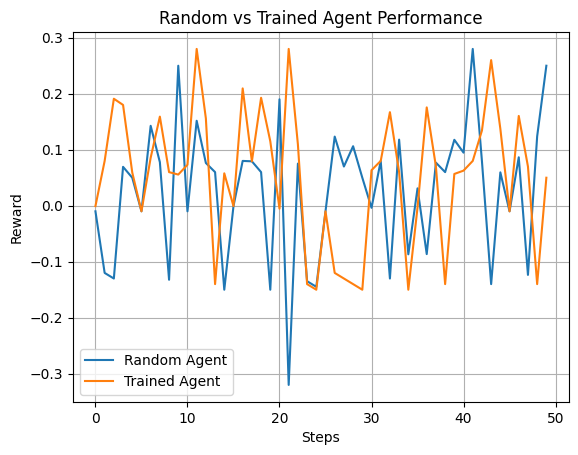

In [17]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(random_rewards, label="Random Agent")
plt.plot(trained_rewards, label="Trained Agent")

plt.legend()
plt.title("Random vs Trained Agent Performance")
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.grid()

plt.show()

In [2]:
!pip install unsloth datasets transformers accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0

In [3]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 512

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/mistral-7b-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = None,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.4.8 patched 32 layers with 32 QKV layers, 32 O layers and 0 MLP layers.


In [6]:
from datasets import Dataset
import random

data = []

actions = [
    {"type": "EXPLAIN", "content": "Explain recursion with example"},
    {"type": "EXPLAIN", "content": "Explain recursion step by step"},
    {"type": "HINT", "content": ""},
    {"type": "QUIZ", "content": ""}
]

for i in range(100):
    action = random.choice(actions)

    data.append({
        "instruction": "Generate a teaching action",
        "input": "",
        "output": str(action)
    })

dataset = Dataset.from_list(data)

In [7]:
def format(example):
    return {
        "text": f"""### Instruction:
{example['instruction']}

### Response:
{example['output']}"""
    }

dataset = dataset.map(format)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [8]:
from transformers import TrainingArguments
from trl import SFTTrainer

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 2,
        warmup_steps = 5,
        max_steps = 50,
        learning_rate = 2e-4,
        logging_steps = 10,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 42,
        output_dir = "outputs",
    ),
)

trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/100 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 100 | Num Epochs = 2 | Total steps = 50
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 13,631,488 of 7,255,363,584 (0.19% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,2.287165
20,0.430032
30,0.170363
40,0.144414
50,0.133321


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-50/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-50.


TrainOutput(global_step=50, training_loss=0.6330589652061462, metrics={'train_runtime': 75.8895, 'train_samples_per_second': 2.635, 'train_steps_per_second': 0.659, 'total_flos': 289303232643072.0, 'train_loss': 0.6330589652061462, 'epoch': 2.0})

In [9]:
model.save_pretrained("unsloth_tutor_model")
tokenizer.save_pretrained("unsloth_tutor_model")

Unsloth: Restored added_tokens_decoder metadata in unsloth_tutor_model/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in unsloth_tutor_model.


('unsloth_tutor_model/tokenizer_config.json',
 'unsloth_tutor_model/tokenizer.json')